# Intro

In this tutorial, we show the robustness of ARGEN to dropping confounding genes. This tutorial generates Fig. 4d,e,f.

# Setting directory and loading required packages

In [1]:
if (!requireNamespace("pacman", quietly = TRUE)) install.packages("pacman", repos = "https://cloud.r-project.org")

pacman::p_load(
  here, dplyr, purrr, tibble, ggpubr, tidyr,
  igraph, ggraph, scales, patchwork, grid
)

DIR <- here::here()
ncores=5

# Read in data

In [2]:
chrlist=paste0('chr',c(1:22,"X"))
chr=23
    


# -------------------------------
# Paths / output
# -------------------------------
DAG_DIR <- paste0(DIR,'/results/application/chr_specific/',chrlist[chr])

if (!dir.exists(DAG_DIR)) dir.create(DAG_DIR, recursive = TRUE, showWarnings = FALSE)

# -------------------------------
# Load data (your paths)
# -------------------------------
X_raw  <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/X_raw_",chrlist[chr],'.rds'))
meta_data <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/meta_data_",chrlist[chr],'.rds'))


# Drop MED12

In [3]:
dropped="MED12"
exclude_gene_id=unique(meta_data$gene_id[meta_data$gene==dropped])
exclude_cell_id=meta_data$cell_barcode[meta_data$gene==dropped]
X_raw=X_raw[!rownames(X_raw)%in%exclude_cell_id,!colnames(X_raw)%in%exclude_gene_id]
meta_data =meta_data  %>% filter(!cell_barcode%in%exclude_cell_id)

# Run ARGEN with MED12 dropped

In [4]:
source(paste0(DIR,'/code/function/Proxy_IV_functions_parallel.R'))

# -------------------------------
# Paths / output
# -------------------------------
DAG_DIR <- paste0(DIR,'/results/application/chr_specific/',chrlist[chr])
if (!dir.exists(DAG_DIR)) dir.create(DAG_DIR, recursive = TRUE, showWarnings = FALSE)

# Design matrix D (exactly as you had)
perturbation_unique <- unique(meta_data$gene_id)
meta_data$gene_id <- factor(meta_data$gene_id,
                            levels = unique(meta_data$gene_id))
meta_data$gem_group<-factor(meta_data$gem_group)

D <- model.matrix(~ gene_id - 1, data = meta_data)
colnames(D) <- sub("^gene_id", "", colnames(D))
D <- D[, -c(length(perturbation_unique))]  # keep your exclusion
control_ind <- which(rowSums(D) == 0)

# Offset vector (depth)
C <- meta_data$guide_UMI_sum / mean(meta_data$guide_UMI_sum)


# Basic checks
nodes <- colnames(X_raw)
p <- length(nodes)
options(future.globals.maxSize = 10 * 1024^3) 
ds_out <- build_descendants_cov_adjust(
  X_raw = X_raw,
  D = D, 
  control_ind = control_ind,
  alpha_desc = 0.05, nodes = nodes,
  padj_method = "BH",
  cc_cols=c('mitopercent'),
  cc_df=meta_data %>% as.data.frame,depth=C,
  ncores = ncores, engine = "multisession", blas_threads = 1
)
alpha_IV <- 0.05


dag_obj <- dag_search_perturbseq(
  desc_sets = ds_out$descendant_set_score_closure,
  data_raw  = X_raw ,
  D = D ,depth =C,family = 'poisson',cc_df=data.frame(meta_data),
  cc_cols = c('mitopercent'),alpha_parent=alpha_IV,
  padj_method_parent='onlineBH',
  cores = ncores, blas_threads = 1
)

# Save DAG artifact (cache)
edges_k <- edges_from_dagsearch(dag_obj)
maps_k  <- compute_ancestors_map(nodes, edges_k)
dag_artifact <- list(
  dag_object    = dag_obj,
  dag_edges     = edges_k,
  parents_map   = maps_k$parents_map,
  ancestors_map = maps_k$ancestors_map
)

setwd(DAG_DIR)
saveRDS(dag_artifact, file = file.path(DAG_DIR,  'dag_0.05BH_0.05onlineBH_dropMED12.rds'))




Node 23 done
Node 22 done
Node 21 done
Node 20 done
Node 19 done
Node 18 done
Node 17 done
Node 16 done
Node 15 done
Node 14 done
Node 13 done
Node 12 done
Node 11 done
Node 10 done
Node 9 done
Node 8 done
Node 7 done
Node 6 done
Node 5 done
Node 4 done
Node 3 done
Node 2 done
Node 1 done


# Functions to summarize results.

In [5]:
# =========================================================
# 3) Helper utilities
#    - pick_col: find first matching alias in names
# =========================================================
pick_col <- function(nm, aliases, fallback = NULL) {
  cand <- intersect(aliases, nm)
  if (length(cand)) cand[1] else fallback
}

# =========================================================
# 4) Safe converter for one edge df
#    Input df may have 'from'/'to' under various aliases; keeps BOTH:
#      * from_id, to_id
#      * from_name_raw, to_name_raw (original symbols)
#      * from_name, to_name         (fallbacked display names)
# =========================================================
convert_edges <- function(df) {
  if (is.null(df)) return(NULL)
  if (!is.data.frame(df)) df <- as.data.frame(df, stringsAsFactors = FALSE)
  if (!nrow(df)) return(df)

  nm <- names(df)

  # common aliases; if missing, fall back to first two columns
  from_aliases <- c("from", "source", "src", "parent", "u")
  to_aliases   <- c("to",   "target", "dst", "child",  "v")

  from_col <- pick_col(nm, from_aliases, fallback = if (length(nm) >= 1) nm[1] else NULL)
  to_col   <- pick_col(nm, to_aliases,   fallback = if (length(nm) >= 2) nm[2] else NULL)
  if (is.null(from_col) || is.null(to_col)) {
    stop("convert_edges(): couldn't identify 'from'/'to' columns in an edge frame.")
  }

  coef_col <- if ("coef" %in% nm) "coef" else NULL
  pval_col <- if ("p_raw" %in% nm) "p_raw" else NULL      

  out <- tibble(
    from_id = as.character(df[[from_col]]),
    to_id   = as.character(df[[to_col]]),
    coef    = if (!is.null(coef_col)) suppressWarnings(as.numeric(df[[coef_col]])) else NA_real_,
    p_raw    = if (!is.null(pval_col)) suppressWarnings(as.numeric(df[[pval_col]])) else NA_real_        
  )

  # attach original symbols and fallbacked display names
  out <- out %>%
    left_join(id2name, by = c("from_id" = "gene_id")) %>%
    dplyr::rename(from_name_raw = gene) %>%
    left_join(id2name, by = c("to_id" = "gene_id")) %>%
    dplyr::rename(to_name_raw = gene) %>%
    mutate(
      from_name = if_else(is.na(from_name_raw) | from_name_raw == "", from_id, from_name_raw),
      to_name   = if_else(is.na(to_name_raw)   | to_name_raw   == "", to_id,   to_name_raw)
    ) %>%
    dplyr::select(from_id, to_id, from_name_raw, to_name_raw, from_name, to_name, coef,p_raw)

  out
}


# Grabbing sub-graph involving dropped gene MED12 as a confounder

## Reading in ARGEN fit without MED12.

In [6]:
DAG_DIR <- paste0(DIR,'/results/application/chr_specific/',chrlist[chr])
setwd(DAG_DIR)

dag_artifact <- readRDS(file = 'dag_0.05BH_0.05onlineBH_dropMED12.rds')

sig_edges=dag_artifact$dag_edges
sig_edges=sig_edges %>%   mutate(edge_id=paste0(from,"_",to))    

id2name <- meta_data %>%
  distinct(gene_id, gene) %>%
  mutate(across(everything(), as.character))    


sig_edges_converted_MED12_drop=convert_edges(sig_edges) %>% dplyr::select("from_name","to_name","coef","p_raw")
colnames(sig_edges_converted_MED12_drop)=c("from","to","coef","p_raw")

## Reading in ARGEN fit with MED12 (ran in Tutorial 3).

In [7]:
DAG_DIR <- paste0(DIR,'/results/application/chr_specific/',chrlist[chr])
setwd(DAG_DIR)

dag_artifact <- readRDS(file = 'dag_0.05BH_0.05onlineBH.rds')
meta_data <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/meta_data_",chrlist[chr],'.rds'))

sig_edges=dag_artifact$dag_edges
sig_edges=sig_edges %>%   mutate(edge_id=paste0(from,"_",to))    

id2name <- meta_data %>%
  distinct(gene_id, gene) %>%
  mutate(across(everything(), as.character))    


sig_edges_converted_original=convert_edges(sig_edges) %>% dplyr::select("from_name","to_name","coef","p_raw")
colnames(sig_edges_converted_original)=c("from","to","coef","p_raw")

## Sub-graph summary.

In [8]:
dropped="MED12"

#original DAG keep only the subgraph having the dropped one and the children within the graph.

child_dropped=(sig_edges_converted_original %>% filter(from=="MED12"))$to %>% unique
sig_edges_converted_original_sub=sig_edges_converted_original %>% filter((from%in%c(dropped,child_dropped))
                                                                                     &(to%in%c(child_dropped)))

#dropped DAG keep only the subgraph having the children of the dropped node within the graph.
sig_edges_converted_MED12_drop_sub=sig_edges_converted_MED12_drop %>% filter(
  paste0(from,'_',to)%in%paste0(sig_edges_converted_original_sub$from,"_",sig_edges_converted_original_sub$to)
) 

#omit the one having only dropped-> children but no edges among the children.
sig_edges_converted_original_sub =sig_edges_converted_original_sub %>% filter(!(from==dropped&!to%in%unique(c(sig_edges_converted_MED12_drop_sub$from,sig_edges_converted_MED12_drop_sub$to))))



sig_edges_converted_MED12_drop_sub=sig_edges_converted_MED12_drop_sub %>% mutate(id=paste0(from,"_",to))
sig_edges_converted_original_sub=sig_edges_converted_original_sub %>% mutate(id=paste0(from,"_",to))

# Fig.4d,e

Warning message:
“`as.undirected()` was deprecated in igraph 2.1.0.
ℹ Please use `as_undirected()` instead.”
Warning message:
“`get.edgelist()` was deprecated in igraph 2.0.0.
ℹ Please use `as_edgelist()` instead.”
Warning message:
“The `label.size` argument of `geom_label()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `linewidth` argument instead.”


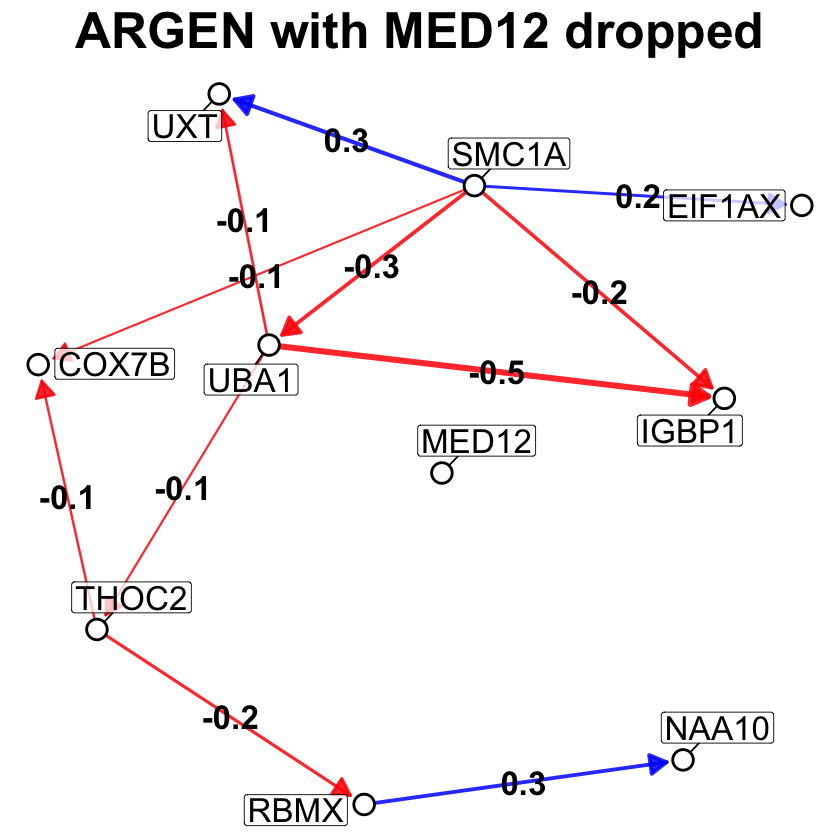

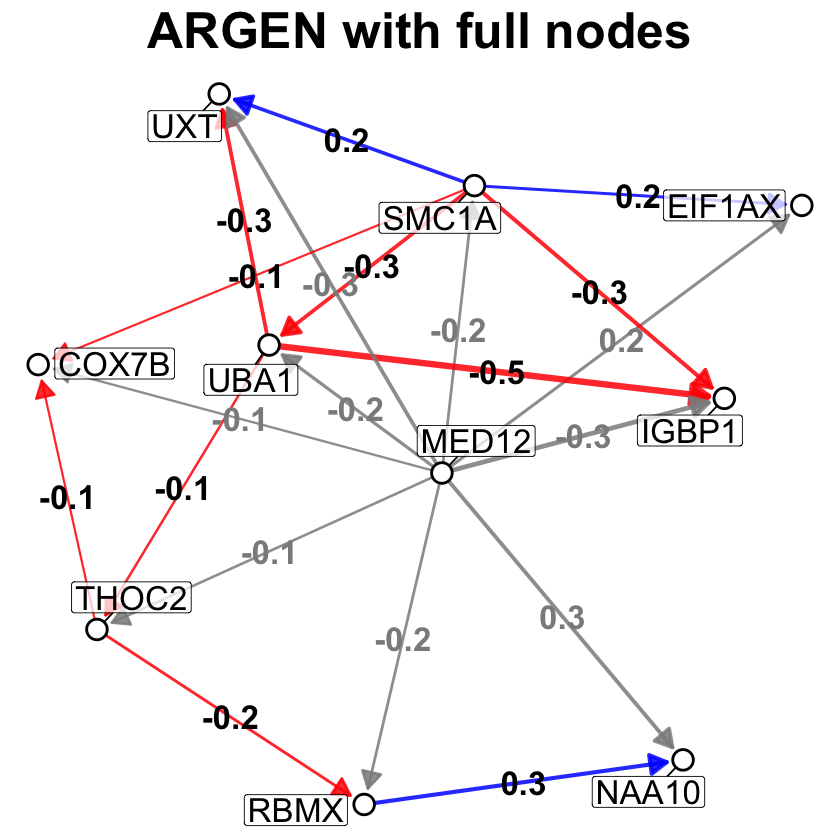

In [9]:
options(repr.plot.width = 7, repr.plot.height = 7)
set.seed(1)


gA <- sig_edges_converted_MED12_drop_sub
gB <- sig_edges_converted_original_sub

# Shared nodes & layout
all_nodes <- sort(unique(c(gA$from, gA$to, gB$from, gB$to)))
g_union <- graph_from_data_frame(
  bind_rows(gA %>% dplyr::select(from,to), gB %>% dplyr::select(from,to)),
  directed = TRUE,
  vertices = tibble(name = all_nodes)
)
pos   <- layout_with_kk(as.undirected(g_union, mode = "collapse"))
posdf <- tibble(name = V(g_union)$name, x = pos[,1], y = pos[,2])
rng_abs <- range(abs(c(gA$coef, gB$coef)), na.rm = TRUE)

plot_one <- function(df, title = "") {
  g <- graph_from_data_frame(df, directed = TRUE, vertices = tibble(name = all_nodes))

  E(g)$coef   <- as.numeric(df$coef)
  E(g)$absw   <- abs(E(g)$coef)
  E(g)$w_plot <- scales::rescale(E(g)$absw, to = c(0.6, 1.8), from = rng_abs)

  # attach source vertex names to edges
  edgelist_names <- igraph::get.edgelist(g, names = TRUE)
  E(g)$from_name <- edgelist_names[, 1]

  # final edge colors
  E(g)$col <- ifelse(E(g)$from_name == dropped, "gray55",
                     ifelse(E(g)$coef < 0, "red", "blue"))

  # manual layout coordinates in the same order as vertices in g
  xy <- posdf[match(V(g)$name, posdf$name), c("x","y")]

  # edge-label dataframe (midpoints in layout space)
  edges_df <- igraph::as_data_frame(g, what = "edges") %>%
    mutate(
      x = (xy$x[match(from, posdf$name)] + xy$x[match(to, posdf$name)]) / 2,
      y = (xy$y[match(from, posdf$name)] + xy$y[match(to, posdf$name)]) / 2,
      coef_lab = sprintf("%.1f", coef),   # 1 decimal for legibility
      lab_col = ifelse(from == dropped, 'gray55',
                       "black")#ifelse(coef < 0, "red", "blue")
    )

  ggraph(g, layout = "manual", x = xy$x, y = xy$y) +
    geom_edge_link(
      aes(edge_width = w_plot, edge_colour = col),
      arrow     = arrow(length = unit(4, "mm"), type = "closed"),
      start_cap = circle(2, "mm"),
      end_cap   = circle(3.5, "mm"),
      lineend   = "round",
      alpha = 0.85,
      show.legend = FALSE
    ) +
    # coefficient labels: boxed so they don't get lost on edges
    geom_label(
      data = edges_df,
      aes(x = x, y = y, label = coef_lab, color = lab_col),
      size = 7,
      fontface = "bold",
      label.size = 0,                         # no border
#      fill = scales::alpha("white", 0.75),
      label.padding = unit(0.08, "lines"),
      show.legend = FALSE
    ) +
    geom_node_point(size = 5, stroke = 1.2, shape = 21,
                    fill = "white", color = "black") +
geom_node_label(
  aes(label = name),
  repel = TRUE,
  label.size = 0,
  label.padding = unit(0.15, "lines"),   # was 0.08
  label.r = unit(0.12, "lines"),
  box.padding = unit(0.6, "lines"),      # << spreads labels apart
  point.padding = unit(0.35, "lines"),   # << more distance from nodes
  max.overlaps = Inf,
  force = 4,                             # << stronger repulsion
  force_pull = 0.1,
  max.iter = 1e5,                        # stabilize final placement
  fill = scales::alpha("white", 0.75),
  size = 7
) +
    scale_color_identity(na.translate = FALSE) +
    scale_edge_colour_identity() +
    scale_edge_width_identity() +
    ggtitle(title) +
    theme_void(base_size = 14) +
    theme(
      plot.title = element_text(size = 30, hjust = 0.5,face="bold")
    )
}

pA <- plot_one(gA, paste0("ARGEN with ", dropped," dropped"))
pB <- plot_one(gB, "ARGEN with full nodes")

pA
pB


# Fig.4f

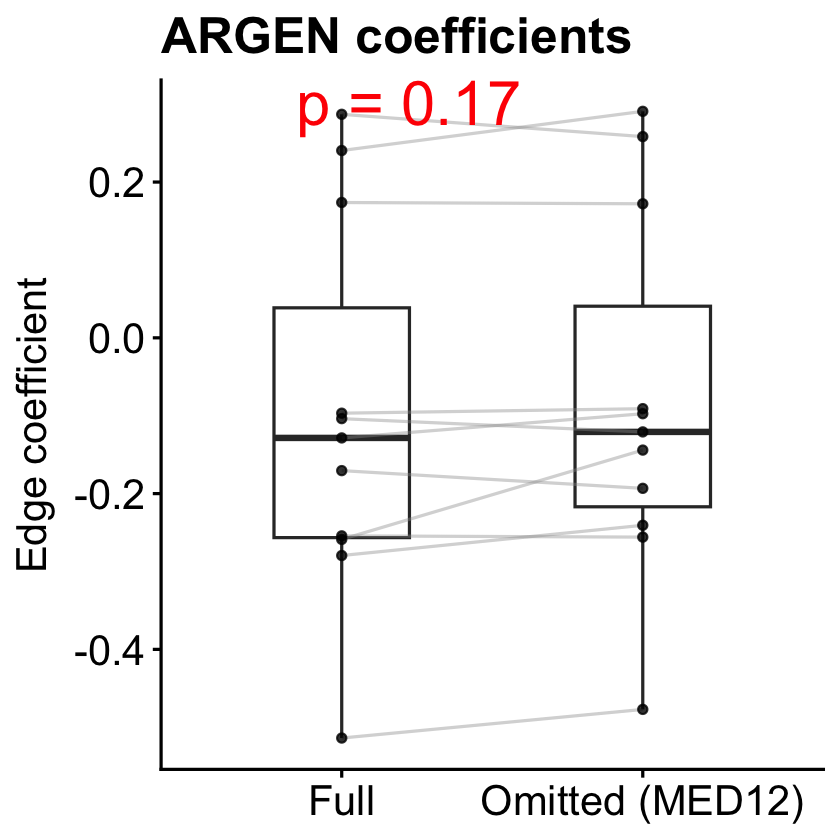

In [10]:
options(repr.plot.width = 7, repr.plot.height = 7)
merged_edges=merge(sig_edges_converted_original_sub,sig_edges_converted_MED12_drop_sub,by = 'id')


plot_df <- merged_edges %>%
  transmute(
    id,
    coef_x = coef.x,
    coef_y = coef.y
  ) %>%
  pivot_longer(
    cols = c(coef_x, coef_y),
    names_to = "condition",
    values_to = "coef"
  ) %>%
  mutate(
    condition = factor(condition,
                       levels = c("coef_x", "coef_y"),
                       labels = c("Full", "Omitted (MED12)"))
  )




g_boxplot <- ggplot(plot_df, aes(x = condition, y = coef)) +
  geom_boxplot(width = 0.45, outlier.shape = NA, alpha = 0.6) +
  geom_line(aes(group = id), color = "grey60", alpha = 0.4) +
  geom_point(size = 2, alpha = 0.8) +
  stat_compare_means(
    paired = TRUE,
    method = "t.test",
    label = "p.format",
    label.y = max(plot_df$coef, na.rm = TRUE) * 0.94, 
    col = 'red', 
    size = 13
  ) +
  labs(
    x = NULL,
    y = "Edge coefficient",
    title = "ARGEN coefficients"
  ) +
  # Apply theme_classic but match the base_size to your previous plot
  theme_classic(base_size = 20) +
  # Add the specific font styling to match the Q-Q plot perfectly
  theme(
    plot.title = element_text(face = "bold", size = 30),
    axis.title = element_text(size=25),
    axis.text = element_text(size=25)
  )
g_boxplot 